In [1]:
import numpy as np
from modrem_utils import *
import matplotlib.pyplot as plt

In [2]:
mem_params = {"vec_len": 10,
              "num_loc_items": 54,
              "num_categories": 3,
              "categories": ["face", "scene", "fruit"],
              "loc_layers": ["visual", "verbal"],
              "main_layers": ["visual"],
              "ic_ratio": 1,
              "num_loc_repeats": 5,
              "beta": 0.4,
              "trial_reset": True,
              "post_tau_style": "exp",    # ["exp", "power", "linear"]
              "post_tau": 8,
              "mem_source": "combined",
              "clf_layers": ["visual"],
              "snr": 5
              }

In [3]:
# Initiate the experiment object
Exp = Modrem_Exp(mem_params)

In [4]:
#  Initiate localizer memories
loc_memories = Exp.create_loc_memories()

In [5]:
# The localizer memories are saved inside the Memories object attached to the Exp object
print(Exp.memories.loc_memories.shape)

(270, 2, 10)


In [5]:
clf = Exp.classifier_train()

Accuracy of classifier was 0.9814814814814815. Training classifier on all loc


Incoming image is scene_14
True


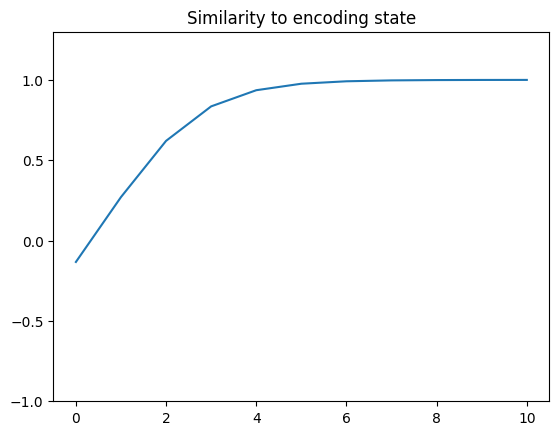

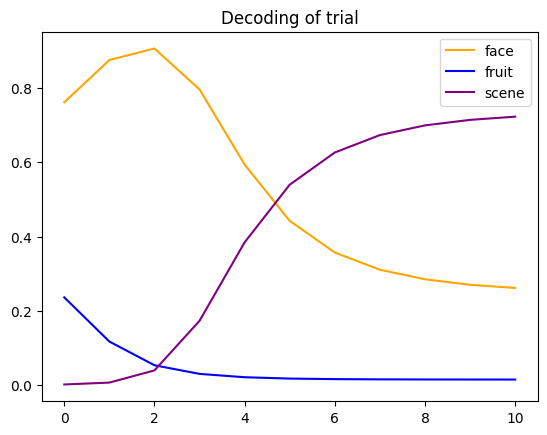

In [9]:
# Simulate the encoding phase
Exp.reset_current_trial()
current_trial = []
for n in range(10):
    current_trial.append(Exp.simulate_encoding_timestep(category="scene"))
    # print(Exp.incoming_state)
print(Exp.current_trial[1:] == current_trial)

x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial)[:, 0], Exp.encoding_state[0])
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to encoding state")
plt.show()

Exp.plot_current_trial()


Incoming image is face_15


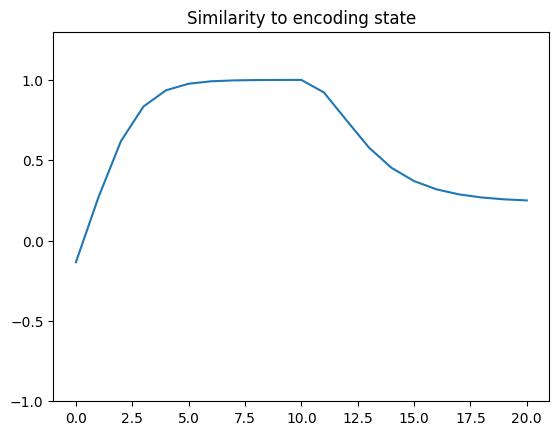

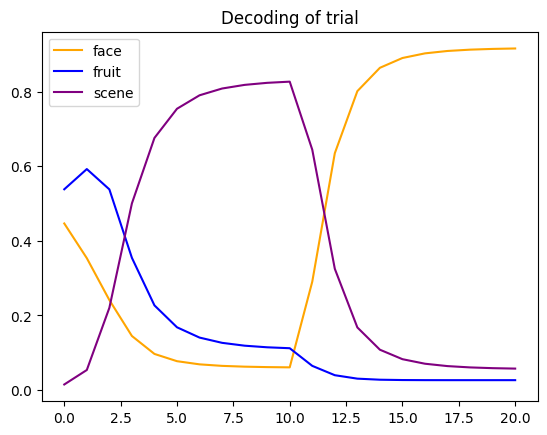

In [8]:
for n in range(10):
    Exp.simulate_replace_timestep()


x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial)[:, 0], Exp.encoding_state[0])
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to encoding state")
plt.show()

# Also graph trial decoding
Exp.plot_current_trial()

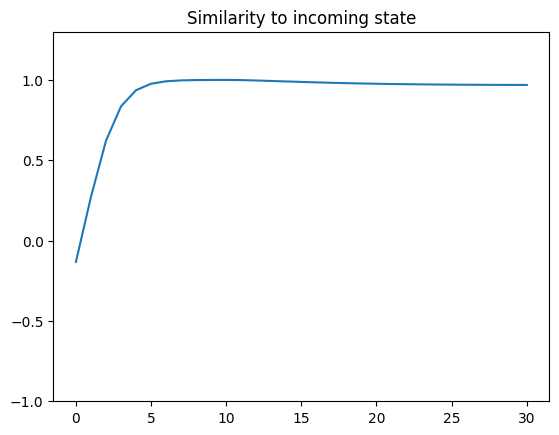

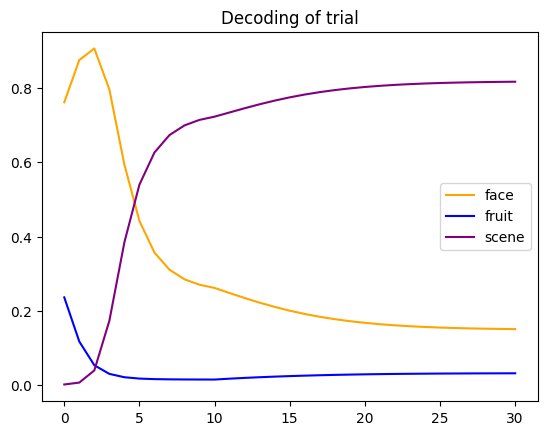

In [11]:
for n in range(10):
    Exp.simulate_maintain_timestep(variant="retrieval", source="combined")

x = np.arange(len(Exp.current_trial))
y = np.dot(np.asarray(Exp.current_trial)[:, 0], Exp.encoding_state[0])
plt.ylim(-1, 1.3)
plt.plot(x, y)
plt.title("Similarity to incoming state")
plt.show()

# Also graph trial decoding
Exp.plot_current_trial()

In [10]:
Exp.current_similarity["scaled"]

array([7.18292986e-06, 1.58686515e-01, 4.05321525e-06, 1.67226183e-06,
       8.81848140e-04, 1.57575024e-06, 2.48446374e-06, 1.04628617e-03,
       4.21177438e-06, 1.03840980e-06, 6.41278860e-06, 4.42710863e-05,
       2.10737946e-06, 2.72263994e-04, 4.75248378e-07, 3.97124993e-06,
       1.72669648e-03, 3.75085068e-07, 3.57700347e-06, 2.73764057e-04,
       6.91301099e-06, 1.78018619e-06, 6.38800351e-04, 7.73246425e-05,
       8.80227339e-07, 1.45837265e-04, 1.50993229e-06, 3.31697868e-06,
       1.10497463e-03, 3.48231169e-06, 1.11476984e-05, 2.82018081e-02,
       2.75159936e-07, 4.45795418e-07, 1.36211683e-04, 3.07072138e-06,
       1.77608784e-04, 2.34391405e-04, 4.00598783e-06, 3.27893948e-06,
       1.32118580e-03, 5.58304259e-06, 1.25951351e-06, 3.30785070e-04,
       4.85317440e-06, 2.66575949e-06, 4.31668775e-05, 1.61426816e-06,
       3.81626839e-07, 1.89663959e-03, 5.37482071e-07, 2.97184601e-06,
       2.62595610e-03, 3.45536382e-05, 7.18292986e-06, 1.58686515e-01,
      

In [11]:
Exp.memories.task_memories.shape

(20, 2, 10)

In [12]:
Exp.memories.loc_memories.shape

(270, 2, 10)

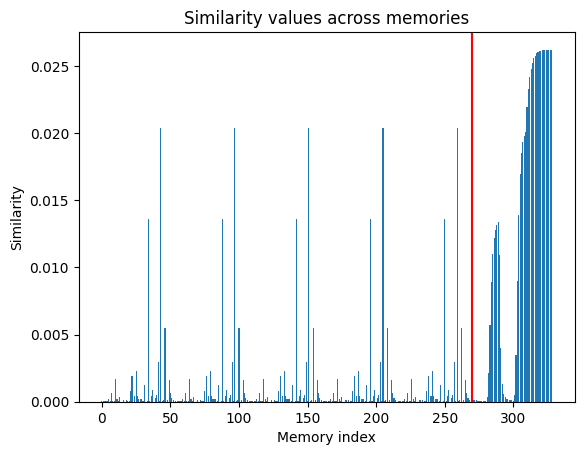

In [12]:
Exp.plot_current_similarity()

incoming state = current_state + external input + memory input

encoding = current_state + external input

maintenance = current_state + memory input


new_contextual_state (encoding condition) = current_contextual_state + external input + memory input

new_encoding_state = current_state + external input ("visual": face, "verbal": noise) + memory input (not implemented)

new_maintenance_state = current_state + external_input ("visual": noise, "verbal": noise) + memory_input

new_replace_state = current_state + external_input ("visual": noise, "verbal": scene) + memory_input